<a href="https://colab.research.google.com/github/liminalvoid/nlp/blob/main/sem_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Семинар 2. Domain Shift, наивный Байес, метрики

## Domain Shift/распределения

### Исходные датасеты

В качестве исходных датасетов используются `data-silence/rus_news_classifier` для классификации новостных текстов и `Kostya165/ru_emotion_dvach` для классификации эмоционального интента.

In [268]:
from datasets import load_dataset


rus_news_ds = load_dataset("data-silence/rus_news_classifier")
ru_emotion_ds = load_dataset("Kostya165/ru_emotion_dvach")

rus_news_ds, ru_emotion_ds

(DatasetDict({
     train: Dataset({
         features: ['news', 'labels'],
         num_rows: 57530
     })
     test: Dataset({
         features: ['news', 'labels'],
         num_rows: 14383
     })
 }),
 DatasetDict({
     train: Dataset({
         features: ['text', 'label'],
         num_rows: 59061
     })
     validation: Dataset({
         features: ['text', 'label'],
         num_rows: 2507
     })
 }))

### Топ-30 log-odds токенов

Извлечение подвыборок из каждого датасета размером 3000 строк.

In [269]:
import numpy as np


def sample_tests(ds, split, n=2000, text_key="text"):
    idx = np.random.choice(len(ds[split]), size=min(n, len(ds[split])), replace=False)

    return [ds[split][int(i)][text_key] for i in idx]


rus_news_train = sample_tests(rus_news_ds, "train", n=3000, text_key="news")
emotion_train = sample_tests(ru_emotion_ds, "train", n=3000)

print("rus_news sampled:", len(rus_news_train))
print("emotion sampled:", len(emotion_train))

rus_news sampled: 3000
emotion sampled: 3000


Вспомогательные функции для калькуляции log-odds.

In [270]:
import re
import math

from collections import Counter
from typing import List


TOKEN_RE = re.compile(r"[А-Яа-яЁё]+(?:-[А-Яа-яЁё]+)?")
simple_tokenize = lambda text, regex: regex.findall(text.lower())


def log_odds_with_smoothing(counts_a: Counter, counts_b: Counter, alpha: float = 0.1):
    """Δ(w)=log((c_a(w)+α)/(N_a+α|V|)) - log((c_b(w)+α)/(N_b+α|V|))"""
    vocab = set(counts_a) | set(counts_b)
    V = len(vocab)
    Na = sum(counts_a.values())
    Nb = sum(counts_b.values())
    deltas = {}

    for w in vocab:
        pa = (counts_a[w] + alpha) / (Na + alpha * V)
        pb = (counts_b[w] + alpha) / (Nb + alpha * V)
        deltas[w] = math.log(pa) - math.log(pb)

    return deltas


def get_tokens(texts, regex=TOKEN_RE):
    for t in texts:
        if t:
            yield from simple_tokenize(t, regex)


def top_log_odds_words(
        texts_a: Counter,
        texts_b: Counter,
        top_n: int = 25,
        alpha: float = 0.1
):
    """
    Функция для калькуляции log-odds для токенов.
    """
    deltas = log_odds_with_smoothing(texts_a, texts_b, alpha=alpha)
    pos = sorted(deltas.items(), key=lambda x: x[1], reverse=True)[:top_n]
    neg = sorted(deltas.items(), key=lambda x: x[1])[:top_n]

    return pos, neg

Log-odds для подвыборок.

In [271]:
import pandas as pd


rus_news_cnt = Counter(get_tokens(rus_news_train))
ru_emotion_cnt = Counter(get_tokens(emotion_train))
pos, neg = top_log_odds_words(rus_news_cnt, ru_emotion_cnt, top_n=30)

rus_news_vs_emotions = pd.DataFrame(pos, columns=["word", "∆(rus_news - emotion)"])
emotions_vs_rus_news = pd.DataFrame(neg, columns=["word", "∆(emotion - rus_news)"])

print("Топ-слова для rus_news (против emotion):")
display(rus_news_vs_emotions)

print("Топ-слова для emotion (против rus_news):")
display(emotions_vs_rus_news)

Топ-слова для rus_news (против emotion):


,word,∆(rus_news - emotion)
0,сообщает,7.282967
1,отметил,6.677300
2,рассказал,6.466526
3,глава,6.361760
4,издание,6.133719
5,ссылкой,6.115772
6,отмечается,6.093801
7,риа,6.090092
8,ноября,6.056075
9,добавил,6.012863


Топ-слова для emotion (против rus_news):


,word,∆(emotion - rus_news)
0,а-а,-8.254882
1,переживаю,-7.826170
2,идиоты,-7.723778
3,гений,-7.480900
4,идиот,-7.445931
5,отличный,-7.205739
6,серьёзным,-7.110881
7,полная,-7.059850
8,хохлы,-7.059850
9,пикабу,-7.006073


### Графики распределений

Увеличение размера графиков.

In [272]:
plt.rcParams["figure.dpi"] = 140

#### Распределение длины документов

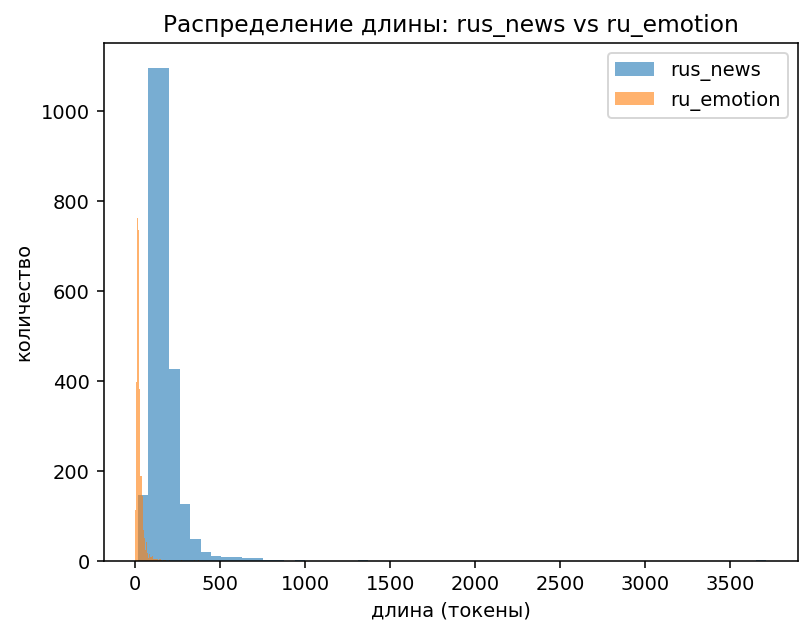

In [273]:
import matplotlib.pyplot as plt


plt.figure()
plt.hist(
    [len(simple_tokenize(t, TOKEN_RE)) for t in rus_news_train if t],
    bins=60,
    alpha=0.6,
    label="rus_news",
)
plt.hist(
    [len(simple_tokenize(t, TOKEN_RE)) for t in emotion_train if t],
    bins=60,
    alpha=0.6,
    label="ru_emotion",
)
plt.legend()
plt.title("Распределение длины: rus_news vs ru_emotion")
plt.xlabel("длина (токены)")
plt.ylabel("количество")
plt.show()

#### Закон Ципфа (частоты топ-100 токенов)

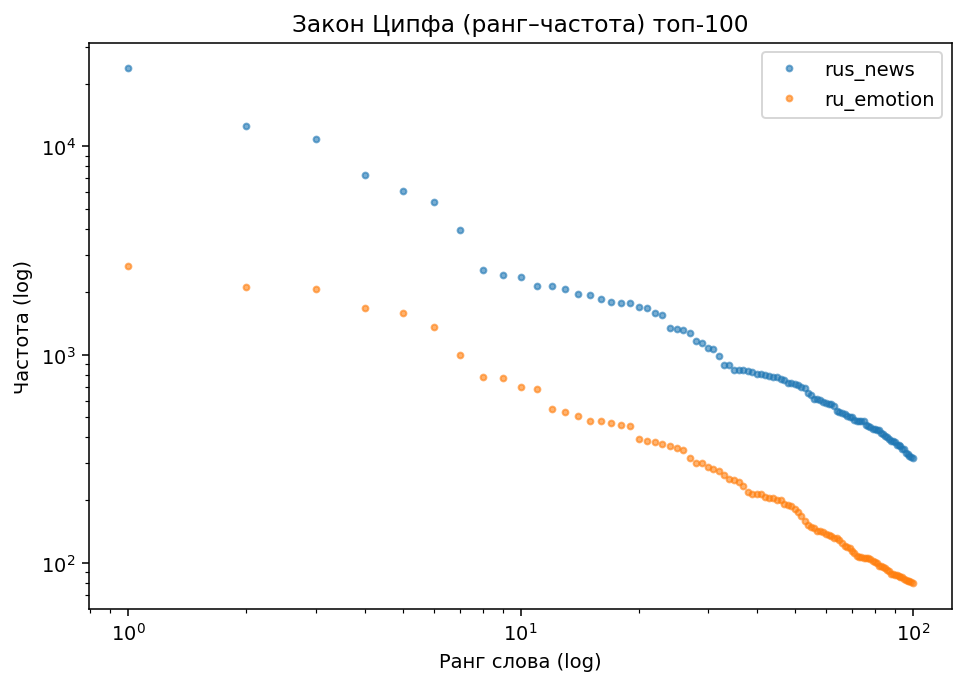

In [274]:
news_freqs_sorted = np.array([v for _, v in rus_news_cnt.most_common(100)])
news_ranks = np.arange(1, len(news_freqs_sorted) + 1)

emotion_freqs_sorted = np.array([v for _, v in ru_emotion_cnt.most_common(100)])
emotion_ranks = np.arange(1, len(emotion_freqs_sorted) + 1)

# 3.1 Zipf log-log
plt.figure(figsize=(7,5))
# news
plt.loglog(
    news_ranks,
    news_freqs_sorted,
    marker=".",
    linestyle="none",
    label="rus_news",
    alpha=0.6,
)
# emotion
plt.loglog(
    emotion_ranks,
    emotion_freqs_sorted,
    marker=".",
    linestyle="none",
    label="ru_emotion",
    alpha=0.6,
)
plt.legend()
plt.title("Закон Ципфа (ранг–частота) топ-100")
plt.xlabel("Ранг слова (log)")
plt.ylabel("Частота (log)")
plt.tight_layout()
plt.show()

#### Доля чисел/пунктуации

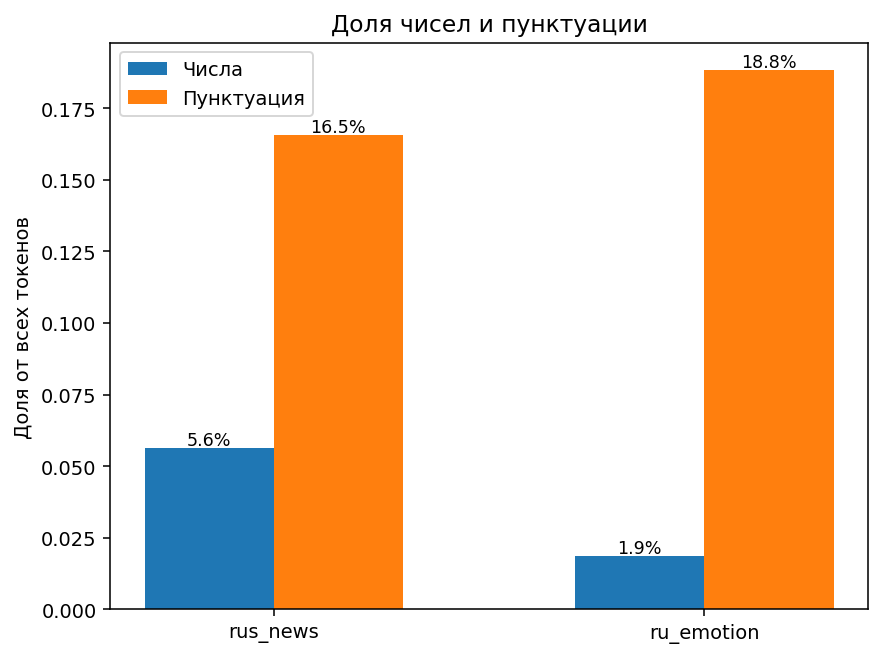

In [275]:
PUNCTUATION_REGEX = re.compile(r"[^\w\s]+")
DIGIT_REGEX = re.compile(r"\d")

rus_news_punctuation_tokens = Counter(get_tokens(rus_news_train, regex=PUNCTUATION_REGEX))
rus_news_digit_tokens = Counter(get_tokens(rus_news_train, regex=DIGIT_REGEX))

emotion_punctuation_tokens = Counter(get_tokens(emotion_train, regex=PUNCTUATION_REGEX))
emotion_digit_tokens = Counter(get_tokens(emotion_train, regex=DIGIT_REGEX))

rus_news_total_tokens = rus_news_cnt.total() + rus_news_digit_tokens.total() + rus_news_punctuation_tokens.total()
emotion_total_tokens = ru_emotion_cnt.total() + emotion_digit_tokens.total() + emotion_punctuation_tokens.total()

news_num = rus_news_digit_tokens.total() / rus_news_total_tokens
news_punct = rus_news_punctuation_tokens.total() / rus_news_total_tokens
emotion_num = emotion_digit_tokens.total() / emotion_total_tokens
emotion_punct = emotion_punctuation_tokens.total() / emotion_total_tokens

labels = ["rus_news", "ru_emotion"]

x = np.arange(len(labels))
width = 0.3

fig, ax = plt.subplots()
ax.bar(
    x - width/2,
    [news_num, emotion_num],
    width,
    label="Числа",
)
ax.bar(
    x + width/2,
    [news_punct, emotion_punct],
    width,
    label="Пунктуация",
)
for i, (n, p) in enumerate(zip([news_num, emotion_num], [news_punct, emotion_punct])):
    ax.text(i - width/2, n + 0.001, f"{n:.1%}", ha='center', fontsize=9)
    ax.text(i + width/2, p + 0.001, f"{p:.1%}", ha='center', fontsize=9)
ax.set_ylabel("Доля от всех токенов")
ax.set_title("Доля чисел и пунктуации")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
plt.tight_layout()
plt.show()

#### Размер словаря

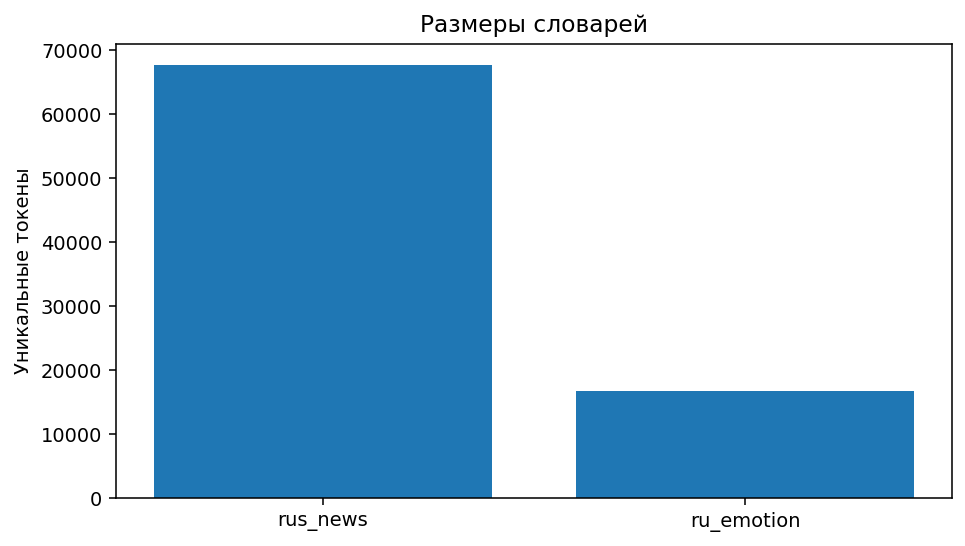

In [276]:
x = np.arange(2)

rus_news_dict_size = len(rus_news_cnt)
emotion_dict_size = len(ru_emotion_cnt)

plt.figure(figsize=(7,4))
plt.bar(
    ["rus_news", "ru_emotion"],
    [rus_news_dict_size, emotion_dict_size],
)
plt.title("Размеры словарей")
plt.ylabel("Уникальные токены")
plt.tight_layout()
plt.show()

### Лемматизация, n-граммы и стоп-слова

#### Лемматизация

In [277]:
!pip -q install pymorphy3 pymorphy3-dicts-ru

In [278]:
import pymorphy3


morph = pymorphy3.MorphAnalyzer()

rus_news_lemmas_cnt = Counter([morph.parse(w)[0].normal_form for w in get_tokens(rus_news_train)])
emotions_lemmas_cnt = Counter([morph.parse(w)[0].normal_form for w in get_tokens(emotion_train)])

Сравнение после лемматизации.

In [279]:
pos, neg = top_log_odds_words(rus_news_lemmas_cnt, emotions_lemmas_cnt, top_n=30)

rus_news_vs_emotion_lemmas = pd.DataFrame(pos, columns=["word (after lemmatization)", "∆(rus_news - emotion)"])
emotion_vs_rus_news_lemmas = pd.DataFrame(neg, columns=["word (after lemmatization)", "∆(emotion - rus_news)"])

print("Топ-слова для rus_news (против emotion):")
display(rus_news_vs_emotion_lemmas)

print("Топ-слова для emotion (против rus_news):")
display(emotion_vs_rus_news_lemmas)

Топ-слова для rus_news (против emotion):


,word (after lemmatization),∆(rus_news - emotion)
0,издание,6.746155
1,коронавирус,6.476812
2,подчеркнуть,6.419668
3,отмечаться,6.203595
4,владимир,6.168061
5,риа,6.045788
6,турист,5.927587
7,тасс,5.927587
8,агентство,5.831063
9,директор,5.783907


Топ-слова для emotion (против rus_news):


,word (after lemmatization),∆(emotion - rus_news)
0,а-а,-8.299186
1,хохол,-7.653999
2,ой,-7.050377
3,пикаба,-7.050377
4,смотреть-ка,-6.869160
5,молодец,-6.869160
6,хохлов,-6.800640
7,хуйня,-6.727078
8,ха-ха,-6.727078
9,зря,-6.647671


#### Разбиение на n-граммы

In [280]:
import nltk


rus_news_bigrams = Counter(nltk.ngrams(get_tokens(rus_news_train), n=2))
rus_news_trigrams = Counter(nltk.ngrams(get_tokens(rus_news_train), n=3))

ru_emotion_bigrams = Counter(nltk.ngrams(get_tokens(emotion_train), n=2))
ru_emotion_trigrams = Counter(nltk.ngrams(get_tokens(emotion_train), n=3))

Сравнение после разбиения на биграммы.

In [281]:
pos, neg = top_log_odds_words(rus_news_bigrams, ru_emotion_bigrams, top_n=30)

rus_news_vs_emotion_bigrams = pd.DataFrame(pos, columns=["word (bigrams)", "∆(rus_news - emotion)"])
emotion_vs_rus_news_bigrams = pd.DataFrame(neg, columns=["word (bigrams)", "∆(emotion - rus_news)"])

print("Топ-слова для rus_news (против emotion):")
display(rus_news_vs_emotion_bigrams)

print("Топ-слова для emotion (против rus_news):")
display(emotion_vs_rus_news_bigrams)

Топ-слова для rus_news (против emotion):


,word (bigrams),∆(rus_news - emotion)
0,"(по, словам)",7.203078
1,"(этом, сообщает)",7.177724
2,"(стало, известно)",6.476682
3,"(отметил, что)",6.385279
4,"(ранее, в)",6.370998
5,"(ссылкой, на)",6.360152
6,"(известно, что)",6.356510
7,"(со, ссылкой)",6.349187
8,"(риа, новости)",6.307920
9,"(отмечается, что)",6.198765


Топ-слова для emotion (против rus_news):


,word (bigrams),∆(emotion - rus_news)
0,"(а, вдруг)",-8.270091
1,"(кто, бы)",-8.194201
2,"(мог, подумать)",-8.167569
3,"(бы, мог)",-8.167569
4,"(а-а, а-а)",-7.990899
5,"(о, конечно)",-7.871303
6,"(да, конечно)",-7.834330
7,"(всё, равно)",-7.735435
8,"(просто, замечательно)",-7.528276
9,"(о, как)",-7.502368


Сравнение после разбиения на триграммы.

In [282]:
pos, neg = top_log_odds_words(rus_news_trigrams, ru_emotion_trigrams, top_n=30)

rus_news_vs_emotion_trigrams = pd.DataFrame(pos, columns=["word (trigrams)", "∆(rus_news - emotion)"])
emotion_vs_rus_news_trigrams = pd.DataFrame(neg, columns=["word (trigrams)", "∆(emotion - rus_news)"])

print("Топ-слова для rus_news (против emotion):")
display(rus_news_vs_emotion_trigrams)

print("Топ-слова для emotion (против rus_news):")
display(emotion_vs_rus_news_trigrams)

Топ-слова для rus_news (против emotion):


,word (trigrams),∆(rus_news - emotion)
0,"(об, этом, сообщает)",7.271609
1,"(со, ссылкой, на)",6.443072
2,"(стало, известно, что)",6.135719
3,"(ранее, сообщалось, что)",6.120613
4,"(об, этом, сообщается)",5.757613
5,"(этом, сообщает, издание)",5.501284
6,"(материалы, по, теме)",5.491814
7,"(об, этом, в)",5.482254
8,"(в, свою, очередь)",5.462855
9,"(ранее, стало, известно)",5.412643


Топ-слова для emotion (против rus_news):


,word (trigrams),∆(emotion - rus_news)
0,"(я, боюсь, что)",-8.581265
1,"(бы, мог, подумать)",-8.060096
2,"(кто, бы, мог)",-8.060096
3,"(а-а, а-а, а-а)",-7.880780
4,"(а, что, если)",-7.830434
5,"(мог, подумать, что)",-7.641550
6,"(ну, да, конечно)",-7.599081
7,"(уверен, что, это)",-7.531791
8,"(ну, что, ж)",-7.139006
9,"(как, будто, это)",-7.104038


#### Сравнение полученных важных токенов

In [283]:
print("Топ-слова для rus_news (против emotion):")
display(
    pd.concat(
        [
            rus_news_vs_emotions,
            rus_news_vs_emotion_lemmas,
            rus_news_vs_emotion_bigrams,
            rus_news_vs_emotion_trigrams,
        ],
        axis=1,
    )
)

print("Топ-слова для emotion (против rus_news):")
display(
    pd.concat(
        [
           emotions_vs_rus_news,
           emotion_vs_rus_news_lemmas,
           emotion_vs_rus_news_bigrams,
           emotion_vs_rus_news_trigrams,
        ],
        axis=1,
    )
)

Топ-слова для rus_news (против emotion):


,word,∆(rus_news - emotion),word (after lemmatization),∆(rus_news - emotion),word (bigrams),∆(rus_news - emotion),word (trigrams),∆(rus_news - emotion)
0,сообщает,7.282967,издание,6.746155,"(по, словам)",7.203078,"(об, этом, сообщает)",7.271609
1,отметил,6.677300,коронавирус,6.476812,"(этом, сообщает)",7.177724,"(со, ссылкой, на)",6.443072
2,рассказал,6.466526,подчеркнуть,6.419668,"(стало, известно)",6.476682,"(стало, известно, что)",6.135719
3,глава,6.361760,отмечаться,6.203595,"(отметил, что)",6.385279,"(ранее, сообщалось, что)",6.120613
4,издание,6.133719,владимир,6.168061,"(ранее, в)",6.370998,"(об, этом, сообщается)",5.757613
5,ссылкой,6.115772,риа,6.045788,"(ссылкой, на)",6.360152,"(этом, сообщает, издание)",5.501284
6,отмечается,6.093801,турист,5.927587,"(известно, что)",6.356510,"(материалы, по, теме)",5.491814
7,риа,6.090092,тасс,5.927587,"(со, ссылкой)",6.349187,"(об, этом, в)",5.482254
8,ноября,6.056075,агентство,5.831063,"(риа, новости)",6.307920,"(в, свою, очередь)",5.462855
9,добавил,6.012863,директор,5.783907,"(отмечается, что)",6.198765,"(ранее, стало, известно)",5.412643


Топ-слова для emotion (против rus_news):


,word,∆(emotion - rus_news),word (after lemmatization),∆(emotion - rus_news),word (bigrams),∆(emotion - rus_news),word (trigrams),∆(emotion - rus_news)
0,а-а,-8.254882,а-а,-8.299186,"(а, вдруг)",-8.270091,"(я, боюсь, что)",-8.581265
1,переживаю,-7.826170,хохол,-7.653999,"(кто, бы)",-8.194201,"(бы, мог, подумать)",-8.060096
2,идиоты,-7.723778,ой,-7.050377,"(мог, подумать)",-8.167569,"(кто, бы, мог)",-8.060096
3,гений,-7.480900,пикаба,-7.050377,"(бы, мог)",-8.167569,"(а-а, а-а, а-а)",-7.880780
4,идиот,-7.445931,смотреть-ка,-6.869160,"(а-а, а-а)",-7.990899,"(а, что, если)",-7.830434
5,отличный,-7.205739,молодец,-6.869160,"(о, конечно)",-7.871303,"(мог, подумать, что)",-7.641550
6,серьёзным,-7.110881,хохлов,-6.800640,"(да, конечно)",-7.834330,"(ну, да, конечно)",-7.599081
7,полная,-7.059850,хуйня,-6.727078,"(всё, равно)",-7.735435,"(уверен, что, это)",-7.531791
8,хохлы,-7.059850,ха-ха,-6.727078,"(просто, замечательно)",-7.528276,"(ну, что, ж)",-7.139006
9,пикабу,-7.006073,зря,-6.647671,"(о, как)",-7.502368,"(как, будто, это)",-7.104038


## Наивный Баес, оценка